<a href="https://colab.research.google.com/github/Prawira123/Model-Klasifikasi-Lontar-Usada-Rare/blob/main/klasifikasi_fix_astungkara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch pandas scikit-learn openpyxl Sastrawi tqdm matplotlib seaborn --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.6 MB/s eta 0:00:00


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device yang digunakan: {device}")


Device yang digunakan: cpu


In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print("Preview data awal:")
print(df.head())


Saving data_gejala_fix.xlsx to data_gejala_fix.xlsx
Preview data awal:
                                        Gejala_sakit  Jenis_Sakit  \
0              Bayi perutnya sakit seperti mau putus  sakit perut   
1                          Telinga bayi curek/berair        curek   
2       Telinga bayi mengeluarkan cairan atau berair        curek   
3  agak putih matanya si bayi, serta uratnya sepe...      guaman.   
4  Mata bayi terlihat agak putih, uratnya tampak ...      guaman.   

                                          Bahan_Obat  \
0  temu tis, sari lungid, air madu lebah, air jer...   
1                  akar glagah, adas, akar paci-paci   
2  daun sirih lanang, daun rumput rasa, temu gong...   
3  biji mentimun, buah paspasan, subatah enau, wo...   
4  biji mentimun, buah paspasan, subatah enau, wo...   

                      Tata_cara_pengobatan Kelas_jenis_penyakit  
0                                 Di minum          Sakit Perut  
1                  Tiupkan pada telinganya   

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess_text(text):
    if not isinstance(text, str):
        return text
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stemmer.stem(text)
    return text

df['Gejala_casefold'] = df['Gejala_sakit'].str.lower()
df['Gejala_clean'] = df['Gejala_casefold'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
df['Gejala_normalized'] = df['Gejala_clean'].apply(stemmer.stem)

df.to_excel('hasil_preprocessing.xlsx', index=False)

print("\nContoh hasil preprocessing:")
print(df[['Gejala_sakit','Gejala_casefold','Gejala_clean','Gejala_normalized']].head())



Contoh hasil preprocessing:
                                        Gejala_sakit  \
0              Bayi perutnya sakit seperti mau putus   
1                          Telinga bayi curek/berair   
2       Telinga bayi mengeluarkan cairan atau berair   
3  agak putih matanya si bayi, serta uratnya sepe...   
4  Mata bayi terlihat agak putih, uratnya tampak ...   

                                     Gejala_casefold  \
0              bayi perutnya sakit seperti mau putus   
1                          telinga bayi curek/berair   
2       telinga bayi mengeluarkan cairan atau berair   
3  agak putih matanya si bayi, serta uratnya sepe...   
4  mata bayi terlihat agak putih, uratnya tampak ...   

                                        Gejala_clean  \
0              bayi perutnya sakit seperti mau putus   
1                           telinga bayi curekberair   
2       telinga bayi mengeluarkan cairan atau berair   
3  agak putih matanya si bayi serta uratnya seper...   
4  mata bayi terl

In [ ]:
le = LabelEncoder()
df['kelas_encoded'] = le.fit_transform(df['Kelas_jenis_penyakit'])

df.to_excel('hasil_pelabelan.xlsx', index=False)

print("\nContoh hasil pelabelan:")
print(df[['Kelas_jenis_penyakit','kelas_encoded']].drop_duplicates().reset_index(drop=True))



Contoh hasil pelabelan:
      Kelas_jenis_penyakit  kelas_encoded
0              Sakit Perut             18
1                    Curek              1
2                   guaman             27
3                    Jampi              4
4            Perut Kembung             14
5                   Muntah              9
6                    Panas             10
7               Perut kaku             16
8               Sakit Mata             17
9                   Sebaha             19
10               Mual-mual              8
11                  Siksik             21
12                Sembelit             20
13         tubuh kemerahan             34
14                 belahan             25
15                   batuk             24
16          sakit kemaluan             30
17            gatal- gatal             26
18             Kurang gizi              5
19  Menangis terus menerus              6
20                   Diare              2
21                 Mimisan              7
22       

In [ ]:
# Hitung jumlah data per kelas
counts = df['kelas_encoded'].value_counts()

# Filter kelas dengan jumlah data 1
kelas_satu_data = counts[counts == 1]

# Menampilkan kelas dengan hanya 1 data
print("Kelas dengan hanya 1 data:")
print(kelas_satu_data)

# Menampilkan banyaknya jenis penyakit dalam masing-masing kelas
print("\nJumlah jenis penyakit dalam setiap kelas:")
for kelas in kelas_satu_data.index:
    # Menghitung jumlah penyakit unik untuk setiap kelas
    penyakit_unik = df[df['kelas_encoded'] == kelas]['jenis_penyakit'].nunique()
    print(f"Kelas {kelas}: {penyakit_unik} jenis penyakit")



Kelas dengan hanya 1 data:
Series([], Name: count, dtype: int64)

Jumlah jenis penyakit dalam setiap kelas:


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['kelas_encoded'],
    random_state=42
)

print(f"\nJumlah data train: {len(train_df)}")
print(f"Jumlah data test: {len(test_df)}")


Jumlah data train: 337
Jumlah data test: 85


**KFOLD 10 (SPLIT DATA)**

In [ ]:
# from sklearn.model_selection import train_test_split, KFold
# import pandas as pd

# # Split data train dan test
# train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['kelas_encoded'], random_state=42)

# # Menampilkan jumlah data train dan test
# print(f"\nJumlah data train: {len(train_df)}")
# print(f"Jumlah data test: {len(test_df)}")

# # Menggunakan KFold untuk Cross Validation (10 fold)
# kf = KFold(n_splits=10, shuffle=True, random_state=42)

# # Menyusun data kfold untuk training
# for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
#     train_fold = train_df.iloc[train_idx]
#     val_fold = train_df.iloc[val_idx]

#     print(f"\nFold {fold + 1}:")
#     print(f"Jumlah data train: {len(train_fold)}")
#     print(f"Jumlah data validasi: {len(val_fold)}")


In [ ]:
tokenizer = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p1')

def tokenize_texts(df, text_column):
    encodings = tokenizer(
        df[text_column].tolist(),
        padding=True,
        truncation=True,
        max_length=128
    )
    return encodings

train_encodings = tokenize_texts(train_df, 'Gejala_normalized')
test_encodings = tokenize_texts(test_df, 'Gejala_normalized')

print("\nContoh tokenisasi input_ids train:")
print(train_encodings['input_ids'][:2])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]


Contoh tokenisasi input_ids train:
[[2, 338, 21547, 11455, 71, 5079, 1252, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 338, 238, 63, 3798, 1122, 41, 1941, 295, 11029, 63, 1370, 705, 2069, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


In [ ]:
# import math
# import torch
# from torch.utils.data import Dataset, DataLoader

# class DiseaseDataset(Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = labels

#     def __getitem__(self, idx):
#         item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
#         item['labels'] = torch.tensor(self.labels[idx])
#         return item

#     def __len__(self):
#         return len(self.labels)

# # Menghitung batch_size untuk mendapatkan 8 batch train
# desired_train_batches = 8
# train_batch_size = math.ceil(len(train_encodings['input_ids']) / desired_train_batches)

# # Membuat dataset dan dataloader
# train_dataset = DiseaseDataset(train_encodings, train_df['kelas_encoded'].values)
# test_dataset = DiseaseDataset(test_encodings, test_df['kelas_encoded'].values)

# train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# print(f"\nJumlah data train: {len(train_dataset)}")
# print(f"Batch size yang digunakan: {train_batch_size}")
# print(f"Jumlah batch train: {len(train_loader)}")
# print(f"Jumlah batch test: {len(test_loader)}")


In [ ]:
class DiseaseDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = DiseaseDataset(train_encodings, train_df['kelas_encoded'].values)
test_dataset = DiseaseDataset(test_encodings, test_df['kelas_encoded'].values)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"\nJumlah batch train: {len(train_loader)}")
print(f"Jumlah batch test: {len(test_loader)}")



Jumlah batch train: 43
Jumlah batch test: 11


Using device: cpu

Training dengan learning rate = 1e-05


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training dimulai...


...

Epoch 13 selesai - Rata-rata Loss: 0.0553


Epoch 14/15: 100%|██████████| 43/43 [03:21<00:00,  4.68s/it]


Epoch 14 selesai - Rata-rata Loss: 0.0534


Epoch 15/15: 100%|██████████| 43/43 [03:20<00:00,  4.66s/it]


Epoch 15 selesai - Rata-rata Loss: 0.0520

Tabel Perbandingan Rata-rata Loss Akhir:
 Learning Rate  Final Average Loss
       0.00001            0.508847
       0.00002            0.159257
       0.00003            0.090186
       0.00004            0.069983
       0.00005            0.052003


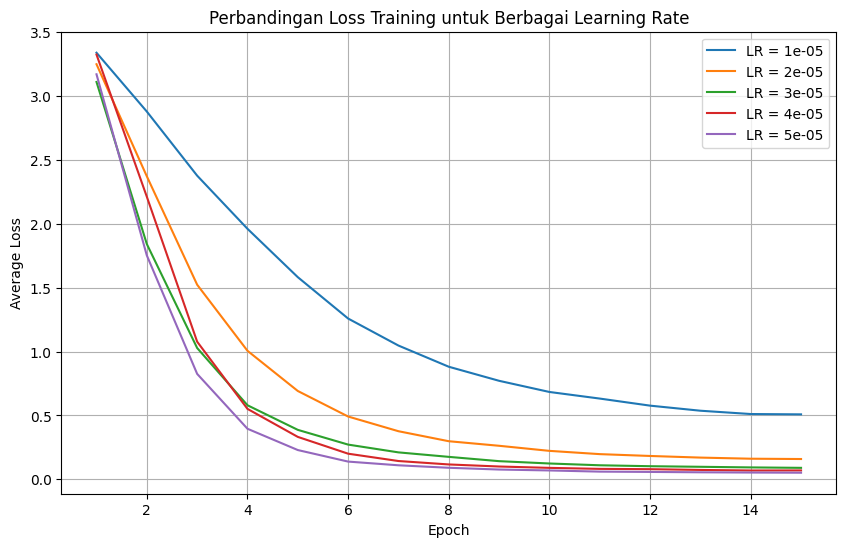

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

# Tentukan range learning rate yang akan diuji
learning_rates = [1e-5, 2e-5, 3e-5, 4e-5, 5e-5]

# Tentukan jumlah epoch
num_epochs = 15

# Setup device GPU jika tersedia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Dictionary untuk menyimpan loss per epoch untuk setiap learning rate
loss_history = {lr: [] for lr in learning_rates}

# Mulai pelatihan dengan mencoba berbagai learning rate
for lr in learning_rates:
    print(f"\nTraining dengan learning rate = {lr}")

    # Pindahkan model ke device (inisialisasi ulang untuk setiap LR agar fair)
    model = BertForSequenceClassification.from_pretrained('indobenchmark/indobert-base-p1', num_labels=len(le.classes_))
    model.to(device)

    # Setup optimizer dan scheduler dengan learning rate yang berbeda
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * num_epochs  # Tentukan jumlah total steps
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    print("\nTraining dimulai...")

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            optimizer.step()
            scheduler.step()

        avg_loss = total_loss / len(train_loader)
        loss_history[lr].append(avg_loss)  # Simpan loss rata-rata per epoch
        print(f"Epoch {epoch+1} selesai - Rata-rata Loss: {avg_loss:.4f}")

# Setelah semua pelatihan selesai, buat tabel dan grafik

# 1. Tabel: Rata-rata loss akhir (epoch terakhir) untuk setiap learning rate
final_losses = {lr: loss_history[lr][-1] for lr in learning_rates}
df = pd.DataFrame(list(final_losses.items()), columns=['Learning Rate', 'Final Average Loss'])
print("\nTabel Perbandingan Rata-rata Loss Akhir:")
print(df.to_string(index=False))

# 2. Grafik: Plot loss over epochs untuk setiap learning rate
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    plt.plot(range(1, num_epochs + 1), loss_history[lr], label=f'LR = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Perbandingan Loss Training untuk Berbagai Learning Rate')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluasi"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

acc = accuracy_score(all_labels, all_preds)
print(f"Akurasi: {acc:.4f}")



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Misal all_labels dan all_preds sudah ada dari evaluasi model

# Ambil kelas unik yang muncul di evaluasi
unique_labels = np.unique(all_labels)
target_names_filtered = [le.classes_[i] for i in unique_labels]

# Buat classification report dengan label dan nama kelas yang sesuai
print(classification_report(all_labels, all_preds, labels=unique_labels, target_names=target_names_filtered))

# Buat confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)

# Visualisasi confusion matrix pakai seaborn heatmap
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_filtered,
            yticklabels=target_names_filtered)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Simpan visualisasi sebagai file gambar (misalnya PNG) untuk download
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Misal kamu sudah punya:
# all_labels = label asli
# all_preds = label hasil prediksi

# Hitung metrik (default average='weighted' untuk multi-class)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
accuracy = accuracy_score(all_labels, all_preds)

# Konversi ke persen dan tampilkan
print("Hasil Evaluasi Model:")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-score : {f1 * 100:.2f}%")
print(f"Accuracy : {accuracy * 100:.2f}%")


In [ ]:
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re

# Fungsi pembersihan input gejala
def preprocess_input(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Fungsi untuk mapping kelas prediksi ke nama kelas asli
def map_to_original_class(predicted_class):
    return le.inverse_transform([predicted_class])[0]

# Fungsi untuk mencari penyakit paling mirip berdasarkan gejala
def find_most_similar_diseases(input_symptoms, top_k=5):  # Set top_k ke 5
    corpus = df['Gejala_sakit'].tolist()
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform([input_symptoms] + corpus)

    cosine_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

    # Menyortir berdasarkan similarity dan memilih 5 teratas
    top_k_idx = np.argsort(cosine_sim)[::-1]

    results = []
    for idx in top_k_idx:
        row = df.iloc[idx]
        results.append({
            'Jenis Penyakit': row['Jenis_Sakit'],
            'Gejala Penyakit': row['Gejala_sakit'],
            'Bahan Obat': row.get('Bahan_Obat', 'Tidak tersedia'),
            'Tata Cara Pengobatan': row.get('Tata_cara_pengobatan', 'Tidak tersedia'),
            'Similarity Score': cosine_sim[idx]
        })

    # Kembali hasil terurut berdasarkan similarity, ambil 5 teratas
    return results[:top_k]

# Fungsi utama prediksi dan rekomendasi penyakit
def predict_and_recommend_topk(symptoms, model, tokenizer, le, top_k=5):  # Set top_k ke 5
    cleaned = preprocess_input(symptoms)
    inputs = tokenizer(cleaned, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        pred_classes = torch.sigmoid(outputs.logits) > 0.5  # Multilabel: threshold > 0.5

    # Ambil semua kelas yang diprediksi relevan
    predicted_classes = pred_classes.cpu().numpy().flatten()
    relevant_classes = [le.inverse_transform([i])[0] for i in range(len(predicted_classes)) if predicted_classes[i] == 1]

    # Cari penyakit yang relevan berdasarkan gejala input
    rekomendasi_terbaik = []
    for kelas_prediksi in relevant_classes:
        rekomendasi_terbaik.extend(find_most_similar_diseases(symptoms, top_k=top_k))  # Ambil top_k rekomendasi

    return {
        "Gejala Input": symptoms,
        "Kelas Prediksi": relevant_classes,
        "Rekomendasi Terbaik": rekomendasi_terbaik
    }

# --- Bagian input manual dan tampilkan hasil ---

if __name__ == "__main__":
    # Menginisialisasi model dan tokenizer
    model = BertForSequenceClassification.from_pretrained(
        'indobenchmark/indobert-base-p1',
        num_labels=len(df['Kelas_jenis_penyakit'].unique())  # Jumlah kelas penyakit
    ).to(device)
    tokenizer = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p1')

    # Contoh input gejala
    test_symptoms = input("Masukkan gejala yang ingin diprediksi (pisahkan dengan koma): ")

    # Mendapatkan rekomendasi
    result = predict_and_recommend_topk(test_symptoms, model, tokenizer, le, top_k=5)  # Set top_k ke 5

    print("\nHasil Prediksi dan Rekomendasi Top-5 Berdasarkan Gejala:")
    print(f"Gejala Input   : {result['Gejala Input']}")
    print(f"Kelas Prediksi : {result['Kelas Prediksi']}")
    print(f"Top {len(result['Rekomendasi Terbaik'])} Rekomendasi Penyakit:")

    for idx, item in enumerate(result['Rekomendasi Terbaik'], 1):
        print(f"{idx}. Jenis Penyakit : {item['Jenis Penyakit']}")
        print(f"   Gejala        : {item['Gejala Penyakit']}")
        print(f"   Bahan Obat    : {item['Bahan Obat']}")
        print(f"   Tata Cara     : {item['Tata Cara Pengobatan']}")
        print(f"   Similarity    : {item['Similarity Score']:.4f}")
        print()


In [ ]:
# ============================================================
# QUICK VERSION - DOWNLOAD SEMUA HASIL DALAM 3 CELL
# ============================================================

# ===========================================================
# CELL 1: SIMPAN SEMUA FILE
# ===========================================================
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import *

print("\n" + "="*70)
print("MENYIMPAN SEMUA HASIL...")
print("="*70)

# Simpan model
model.save_pretrained('./model_indobert_klasifikasi')
tokenizer.save_pretrained('./model_indobert_klasifikasi')
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Hitung metrik
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
accuracy = accuracy_score(all_labels, all_preds)

# Simpan semua hasil ke Excel
unique_labels = np.unique(all_labels)
target_names_filtered = [le.classes_[i] for i in unique_labels]

# Classification report
report_dict = classification_report(all_labels, all_preds, labels=unique_labels,
                                   target_names=target_names_filtered, output_dict=True)
pd.DataFrame(report_dict).transpose().to_excel('classification_report.xlsx')

# Metrik evaluasi
pd.DataFrame({
    'Metrik': ['Precision', 'Recall', 'F1-Score', 'Accuracy'],
    'Nilai': [precision, recall, f1, accuracy],
    'Persentase': [f"{x*100:.2f}%" for x in [precision, recall, f1, accuracy]]
}).to_excel('metrik_evaluasi.xlsx', index=False)

# Data split
train_df.to_excel('data_training.xlsx', index=False)
test_df.to_excel('data_testing.xlsx', index=False)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
pd.DataFrame(cm, index=target_names_filtered, columns=target_names_filtered).to_excel('confusion_matrix.xlsx')

# Hasil prediksi detail
pd.DataFrame({
    'Label_Asli': [le.classes_[label] for label in all_labels],
    'Label_Prediksi': [le.classes_[pred] for pred in all_preds],
    'Benar': [1 if all_labels[i] == all_preds[i] else 0 for i in range(len(all_labels))]
}).to_excel('hasil_prediksi_detail.xlsx', index=False)

print("✓ Semua file tersimpan!")


# ===========================================================
# CELL 2: TAMPILKAN RINGKASAN
# ===========================================================
print("\n" + "="*70)
print("RINGKASAN HASIL KLASIFIKASI")
print("="*70)

excel_files = [
    'hasil_preprocessing.xlsx',
    'hasil_pelabelan.xlsx',
    'data_training.xlsx',
    'data_testing.xlsx',
    'classification_report.xlsx',
    'metrik_evaluasi.xlsx',
    'confusion_matrix.xlsx',
    'hasil_prediksi_detail.xlsx'
]

print("\n📁 FILE YANG TELAH DIBUAT:")
for i, file in enumerate(excel_files, 1):
    print(f"  {i}. ✓ {file}")
print(f"  9. ✓ confusion_matrix.png")
print(f" 10. ✓ label_encoder.pkl")
print(f" 11. ✓ model_indobert_klasifikasi/")

print(f"\n📊 Total Data: {len(df)}")
print(f"📚 Jumlah Kelas: {len(df['Kelas_jenis_penyakit'].unique())}")
print(f"📖 Training: {len(train_df)} | Testing: {len(test_df)}")
print(f"\n🎯 Accuracy:  {accuracy*100:.2f}%")
print(f"🎯 Precision: {precision*100:.2f}%")
print(f"🎯 Recall:    {recall*100:.2f}%")
print(f"🎯 F1-Score:  {f1*100:.2f}%")
print("="*70)


# ===========================================================
# CELL 3: DOWNLOAD SEMUA FILE DALAM ZIP
# ===========================================================
import zipfile
import os
import shutil
from google.colab import files

zip_filename = 'HASIL_KLASIFIKASI_PENYAKIT_INDOBERT.zip'

print("\n" + "="*70)
print("MEMBUAT & DOWNLOAD FILE ZIP")
print("="*70)

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in excel_files + ['confusion_matrix.png', 'label_encoder.pkl']:
        if os.path.exists(file):
            zipf.write(file)

    if os.path.exists('model_indobert_klasifikasi'):
        for root, dirs, files_list in os.walk('model_indobert_klasifikasi'):
            for file in files_list:
                zipf.write(os.path.join(root, file))

print(f"✓ File ZIP dibuat: {zip_filename} ({os.path.getsize(zip_filename)/(1024*1024):.2f} MB)")
files.download(zip_filename)
print("✓ Download selesai!")
print("="*70)